# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

from environment.environment import Environment
from experiment import Experiment
from campaigns.highly_non_stationary_campaign import HighlyNonStationaryCampaign
from bidders.primal_dual.primal_dual_bidder import PrimalDualBidder

import plots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Requirement 3: Best-of-both-worlds with multiple campaigns

### Environment

Use the stochastic environment already designed:
- A joint distribution over the highest competing bids for each campaign

Build a highly non-stationary environment. At a high level, it should include:
- A non-stochastic sequence of highest competing bids for each campaign (e.g., sampled from a distribution that changes quickly over time)

In [6]:
N_TRIALS = 10  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=5, campaign_type=HighlyNonStationaryCampaign, min_competitors=2, max_competitors=5, conflicts_percentage=0.4, seed=47)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 10000  # number of ads to be shown sequentially = n_rounds = T

RHO = 0.2  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

np.random.seed(123)
MY_VALUATIONS = np.random.uniform(low=0.3, high=0.9, size=environment.N_CAMPAIGNS)  # per-campaign valuations; lower bound > smallest non-zero bid (BIDS_SPACE[1] = 0.1) so every campaign has at least one feasible non-zero bid
print("Per-campaign valuations:", MY_VALUATIONS)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 5
Campaigns:
    -- CAMPAIGN: --
    Type: Highly Non-Stationary
    Description: Competing bids sampled from a highly non-stationary distribution which changes quickly over time.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    -- CAMPAIGN: --
    Type: Highly Non-Stationary
    Description: Competing bids sampled from a highly non-stationary distribution which changes quickly over time.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    -- CAMPAIGN: --
    Type: Highly Non-Stationary
    Description: Competing bids sampled from a highly non-stationary distribution which changes quickly over time.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    -- CAMPAIGN: --
    Type: Highly Non-Stationary
    Description: Competing bids sampled from a h

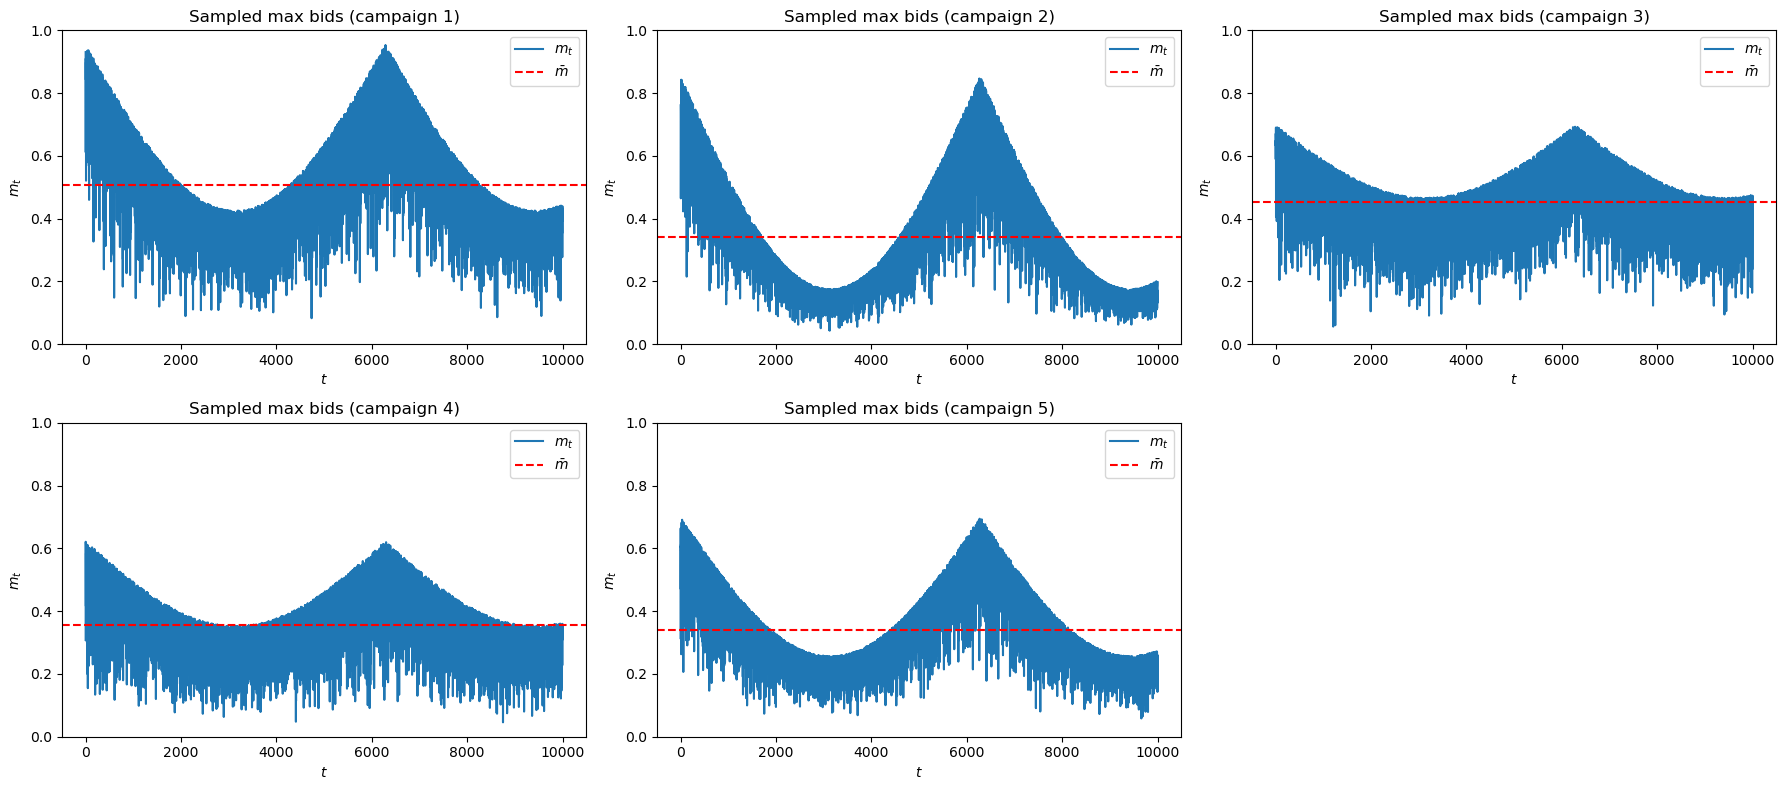

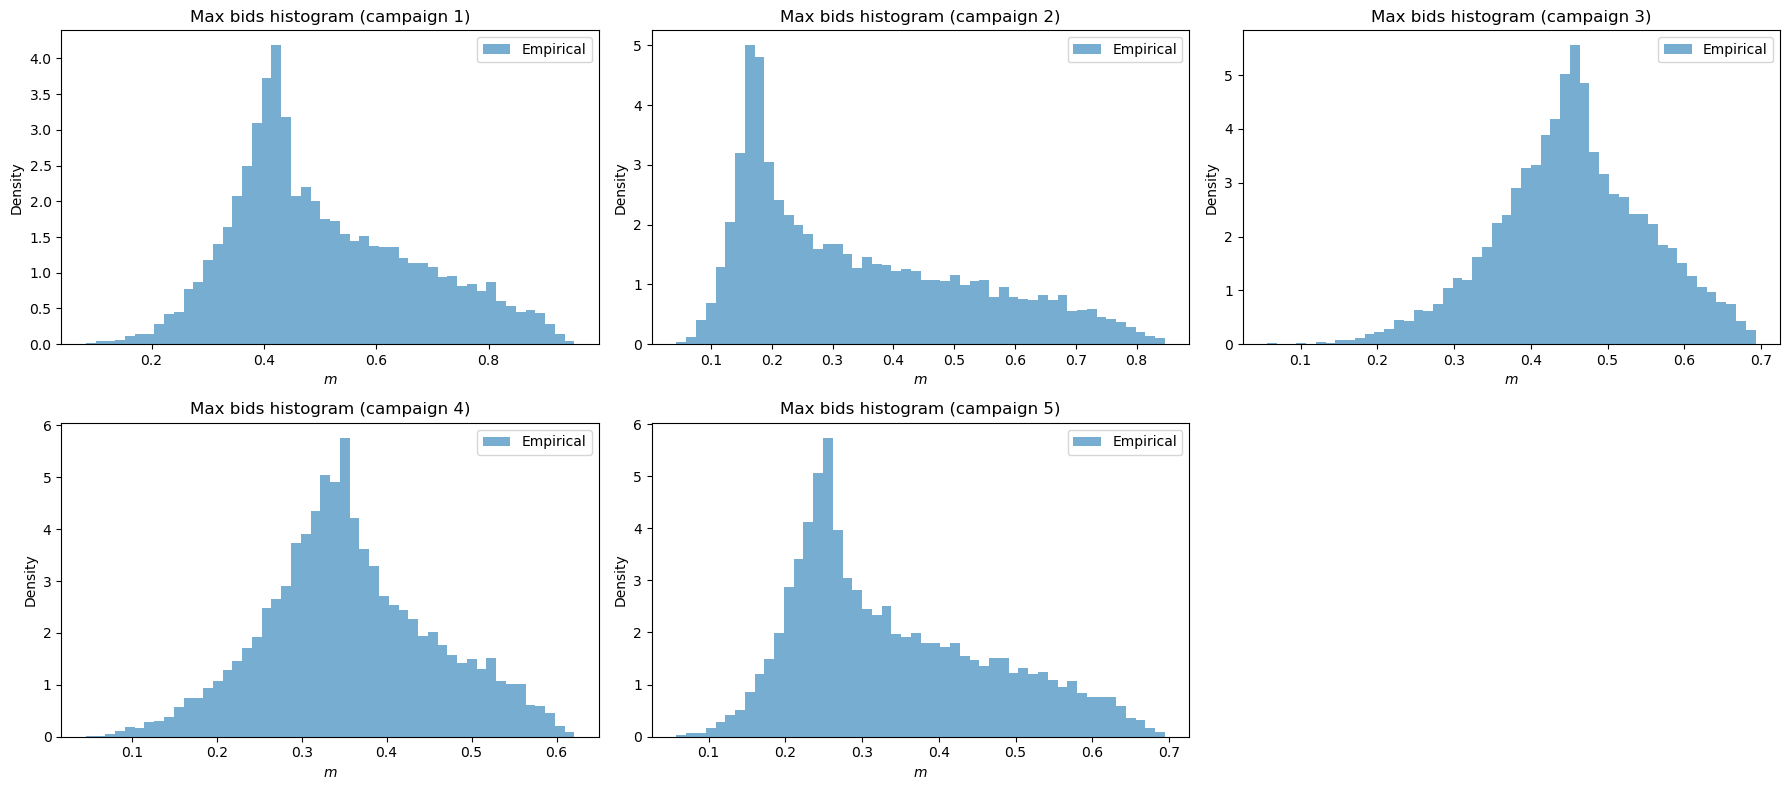

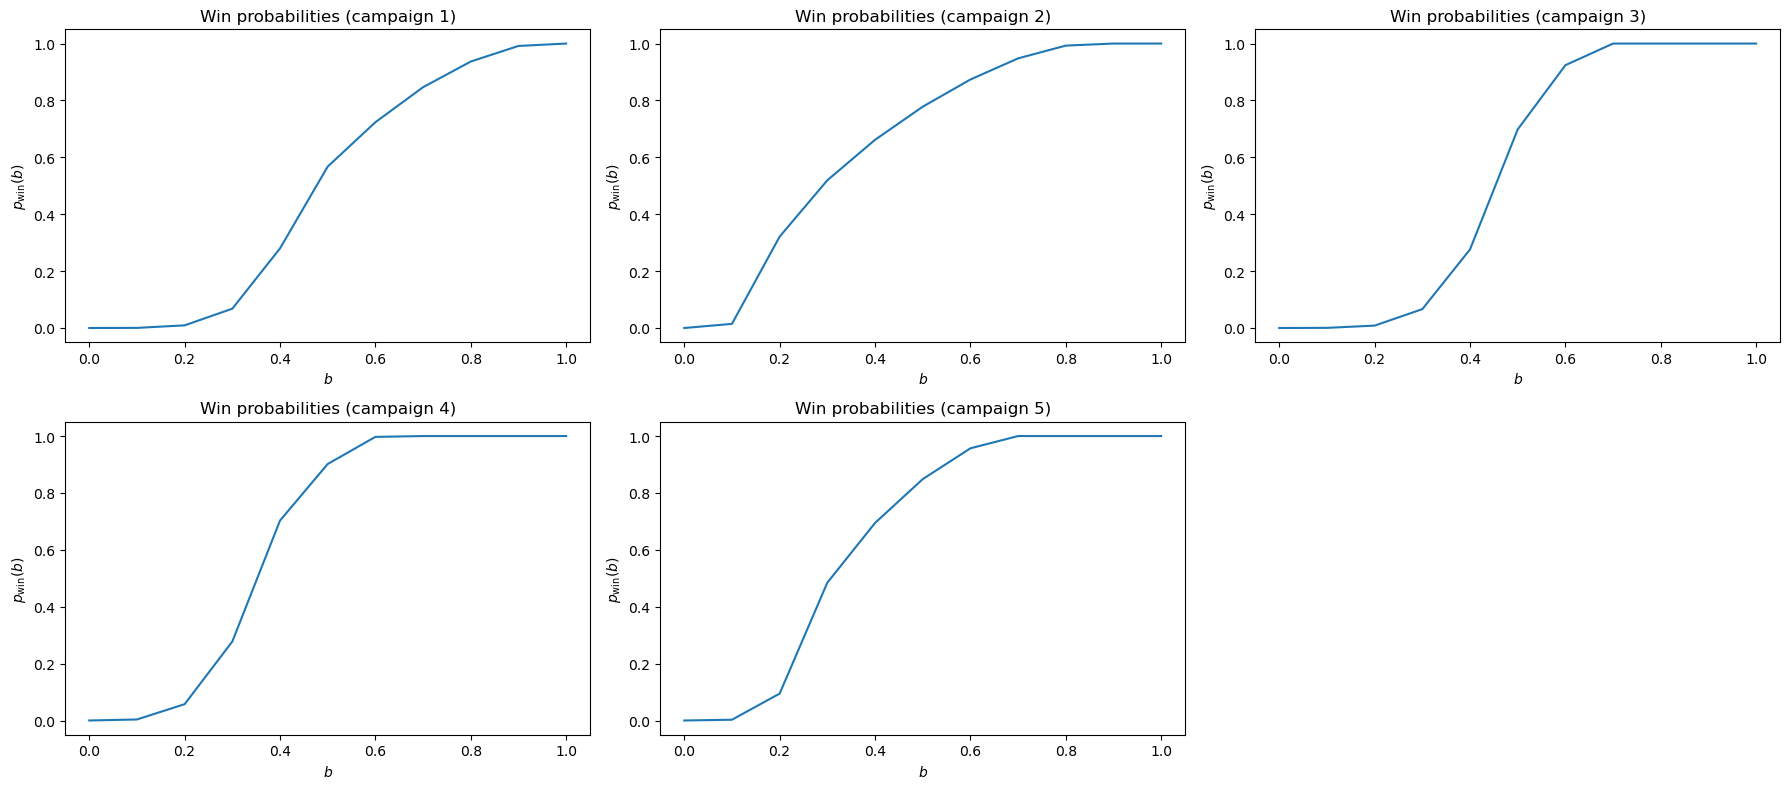

In [7]:
for i, campaign in enumerate(environment.campaigns):
    campaign.generate_random_competing_bids(n_users=N_USERS, seed=47+i)  # generate random competing bids for each advertiser in the campaign

plots.plot_req3_sampled_max_bids_in_time(environment)
plots.plot_req3_max_bids_histogram(environment)
plots.plot_win_probabilities(environment, BIDS_SPACE, 'req3_win_probabilities.png')

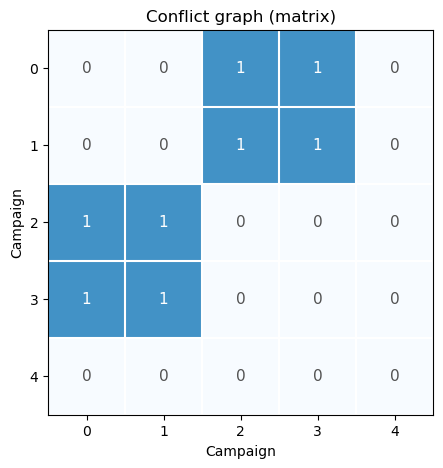

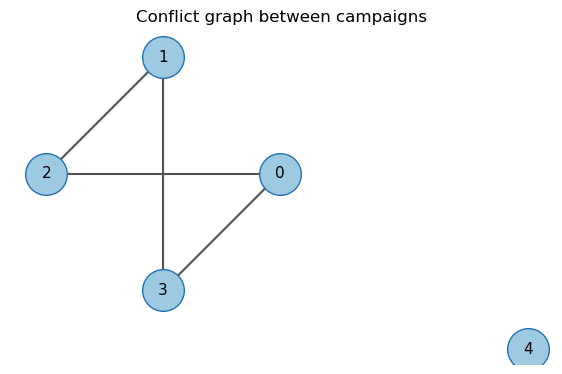

In [8]:
plots.plot_conflict_graph_between_campaigns_matrix_version(environment, 'req3_conflict_matrix.png')
plots.plot_conflict_graph_between_campaigns(environment, 'req3_conflict_graph.png')

### Design best-of-both-worlds algorithms with multiple campaigns

- Build a bidding strategy using a primal-dual method with budget constraint.

Hint: Design a primal regret minimizer for the specific problem under study.

!!! For this requirement, you can assume full feedback, i.e., to observe the highest
competing bid for each auction.

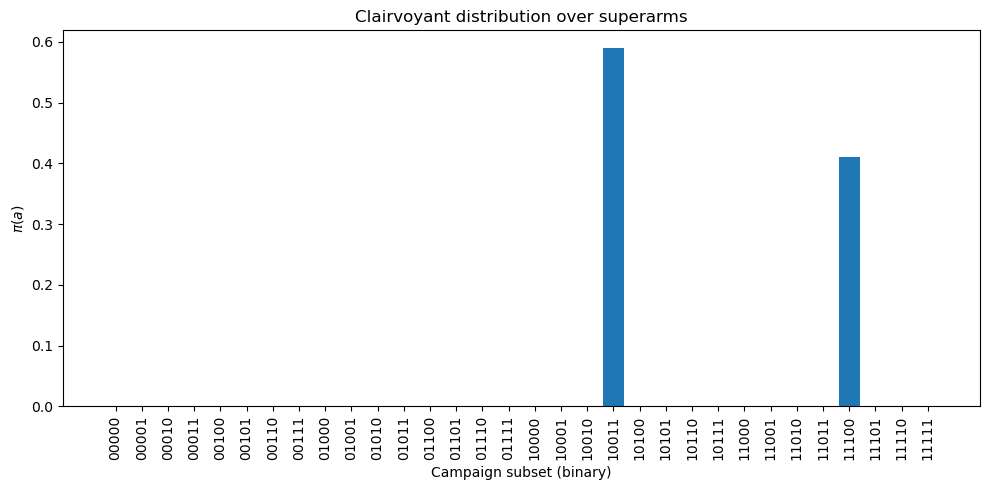

In [9]:
LEARNING_RATE_PRIMAL = 1
LEARNING_RATE_DUAL = 1

auxiliary_bidder = PrimalDualBidder(B=STARTING_BUDGET, T=N_USERS, valuations=MY_VALUATIONS.tolist(), environment=environment, learning_rate_primal=LEARNING_RATE_PRIMAL, learning_rate_dual=LEARNING_RATE_DUAL)

true_clairvoyant_campaign_gammas, true_clairvoyant_superarm_gammas, true_clairvoyant_expected_utilities, true_clairvoyant_expected_payments = environment.compute_true_combinatorial_clairvoyant(auxiliary_bidder, campaign_indices=None)

plots.plot_req3_clairvoyant_distribution_over_campaigns_subsets(superarm_gammas=true_clairvoyant_superarm_gammas)

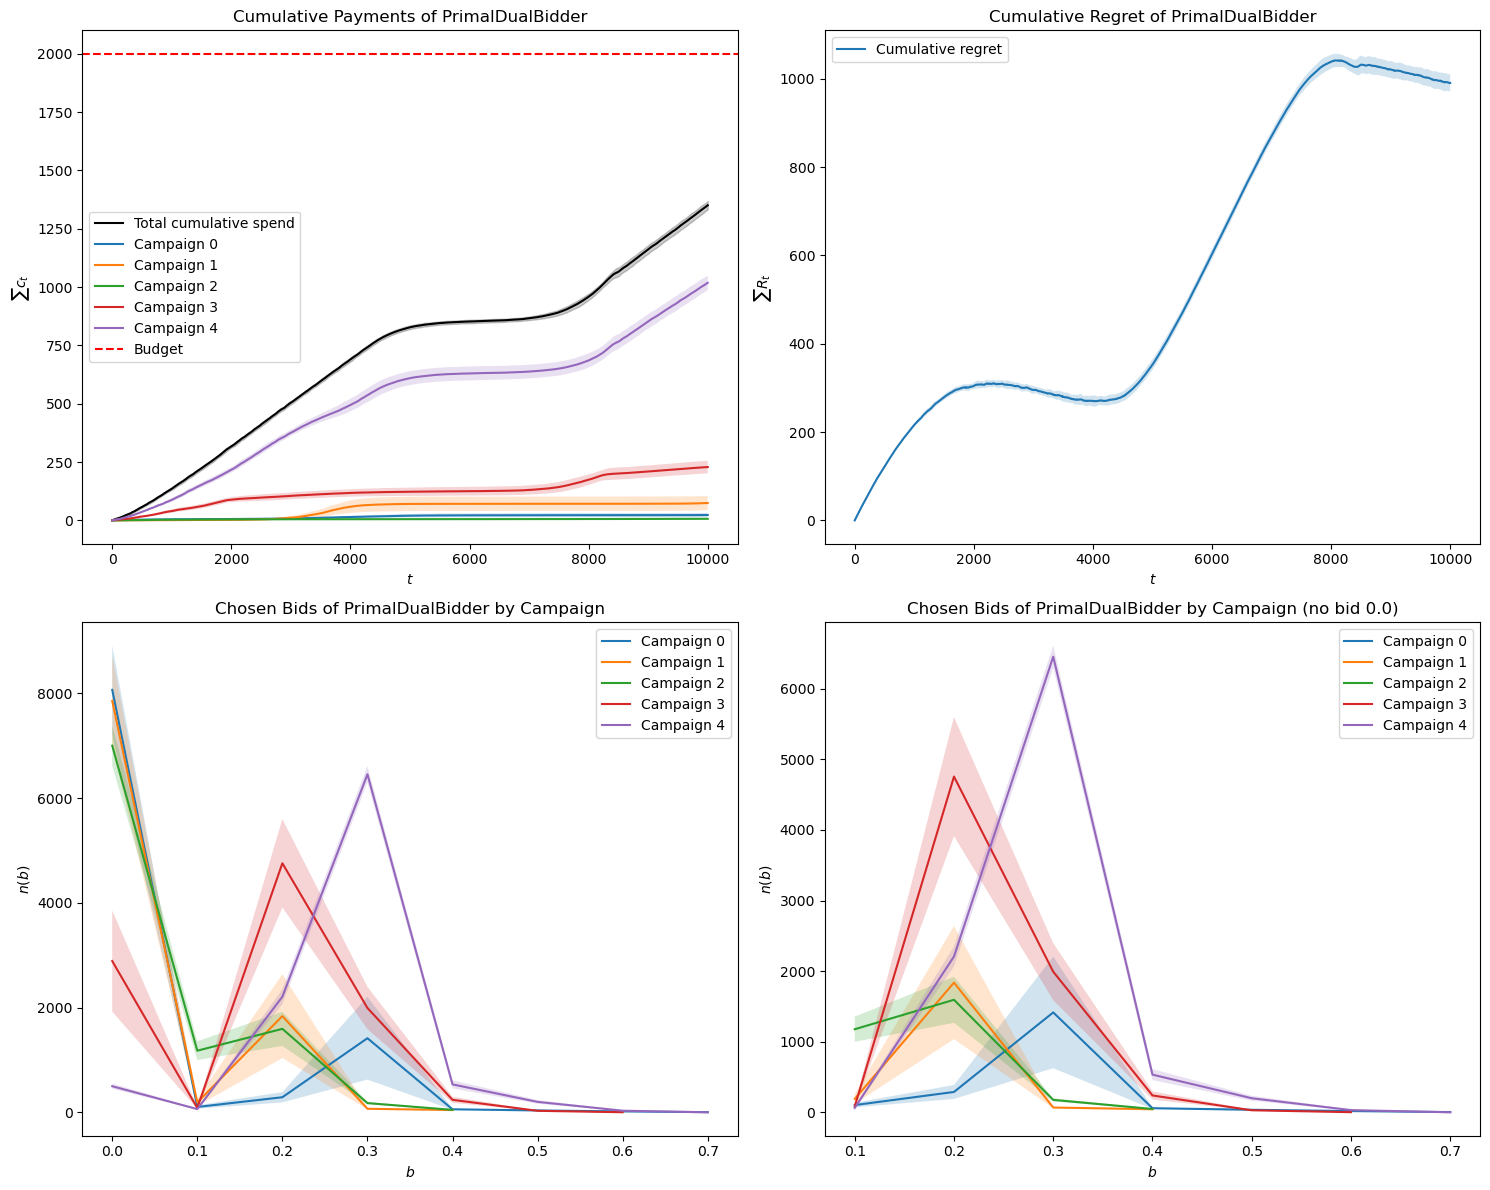

In [10]:
budget_constrained_multiple_campaigns_primal_dual_experiment = Experiment(environment=environment,
                                                          bidder_class=PrimalDualBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': MY_VALUATIONS.tolist(), 
                                                              'environment': environment,
                                                              'learning_rate_primal': LEARNING_RATE_PRIMAL,
                                                              'learning_rate_dual': LEARNING_RATE_DUAL
                                                            })

budget_constrained_multiple_campaigns_primal_dual_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='true', seed=10)

plots.plot_experiment_result(budget_constrained_multiple_campaigns_primal_dual_experiment, "req3_primal_dual_experiment_results.png")

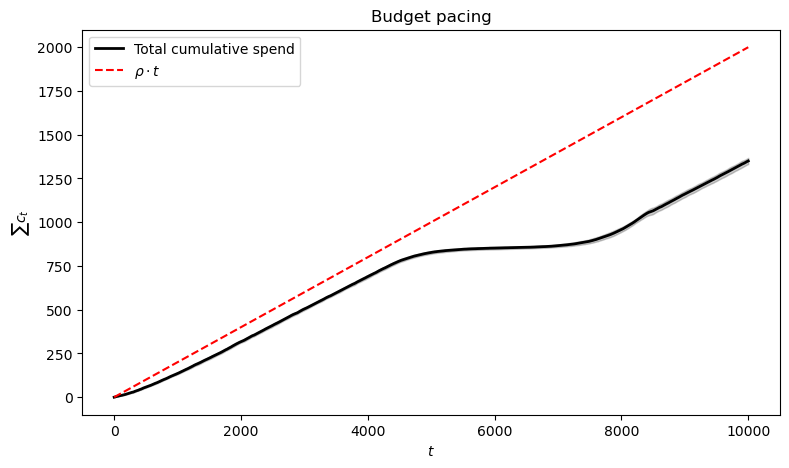

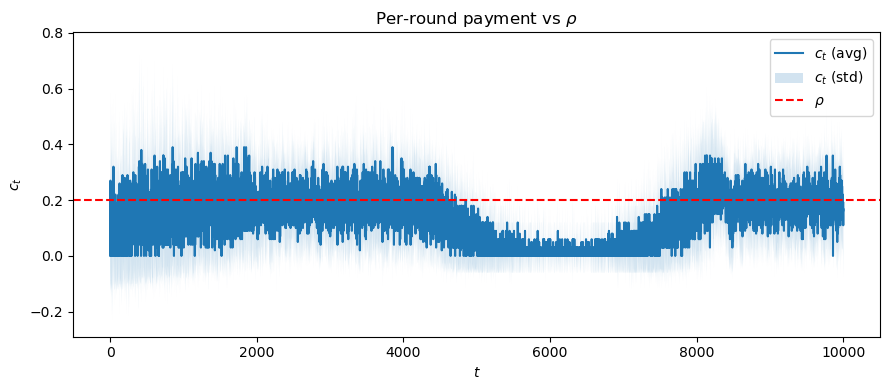

In [11]:
plots.plot_req3_budget_pacing(budget_constrained_multiple_campaigns_primal_dual_experiment)
plots.plot_req3_per_round_payment_vs_rho(budget_constrained_multiple_campaigns_primal_dual_experiment)

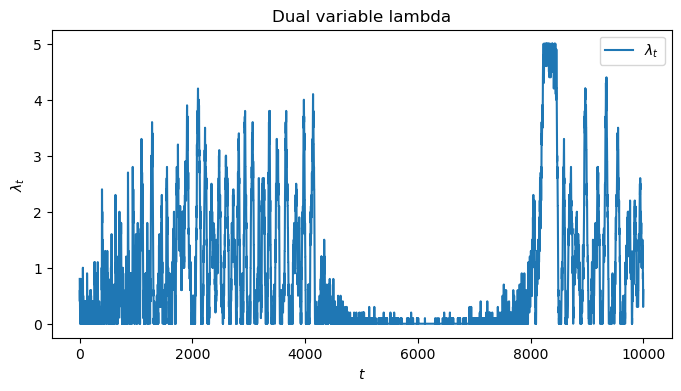

In [12]:
plots.plot_req3_dual_variable_lambda_over_time(budget_constrained_multiple_campaigns_primal_dual_experiment)